### Load USD/INR Exchange Rate Data

*   List item
*   List item



We will use the `yfinance` library to download historical USD/INR exchange rate data. The ticker for USD/INR is typically `INR=X` or `USDINR=X` on Yahoo Finance. We'll use `INR=X` as it's common for currency pairs.

In [1]:
pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

# Define the ticker for USD/INR exchange rate
ticker = 'INR=X'

# Define the start and end dates based on the problem description
start_date = '2004-01-01'
end_date = '2026-08-31'

# Download the data
df_usd_inr = yf.download(ticker, start=start_date, end=end_date)

# Display the first 5 rows of the DataFrame
display(df_usd_inr.head())

/tmp/ipykernel_2767/3542612559.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_usd_inr = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INR=X,INR=X,INR=X,INR=X,INR=X
Date,,,,,
2004-01-01,45.527000,45.532001,45.519001,45.528999,0
2004-01-02,45.603001,45.645000,45.497002,45.527000,0
2004-01-05,45.466000,45.564999,45.459000,45.528000,0
2004-01-06,45.549000,45.604000,45.457001,45.467999,0
2004-01-07,45.387001,45.560001,45.375000,45.548000,0


### Initial Data Exploration

Let's check for any missing values in the dataset and display basic information about the DataFrame, such as column data types and non-null counts.

In [3]:
print('Missing values per column:')
display(df_usd_inr.isnull().sum())

print('\nDataFrame Info:')
display(df_usd_inr.info())

Missing values per column:


,,0
Price,Ticker,
Close,INR=X,0
High,INR=X,0
Low,INR=X,0
Open,INR=X,0
Volume,INR=X,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2004-01-01 to 2026-08-03
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, INR=X)   5856 non-null   float64
 1   (High, INR=X)    5856 non-null   float64
 2   (Low, INR=X)     5856 non-null   float64
 3   (Open, INR=X)    5856 non-null   float64
 4   (Volume, INR=X)  5856 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 274.5 KB


None

### Data Cleaning and Preprocessing

We will now flatten the multi-index column names, select the 'Close' price, and check for any duplicate entries in the index to ensure data integrity.

In [4]:
# Flatten the column names
df_usd_inr.columns = ['_'.join(col).strip() for col in df_usd_inr.columns.values]

# Select only the 'Close' price for the target variable
df_close_price = df_usd_inr[['Close_INR=X']].copy()

# Rename the column for simplicity
df_close_price.rename(columns={'Close_INR=X': 'USD/INR'}, inplace=True)

# Check for duplicate dates in the index
duplicates = df_close_price.index.duplicated()
if duplicates.any():
    print(f'Found {duplicates.sum()} duplicate dates. Removing them.')
    df_close_price = df_close_price[~duplicates]
else:
    print('No duplicate dates found in the index.')

# Display the first few rows of the preprocessed data
display(df_close_price.head())

# Display the info of the new DataFrame
display(df_close_price.info())

No duplicate dates found in the index.


,USD/INR
Date,
2004-01-01,45.527000
2004-01-02,45.603001
2004-01-05,45.466000
2004-01-06,45.549000
2004-01-07,45.387001


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2004-01-01 to 2026-08-03
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD/INR  5856 non-null   float64
dtypes: float64(1)
memory usage: 91.5 KB


None

### Visualize the USD/INR Exchange Rate Data

Now, let's plot the 'USD/INR' exchange rate over time to observe its trends and patterns.

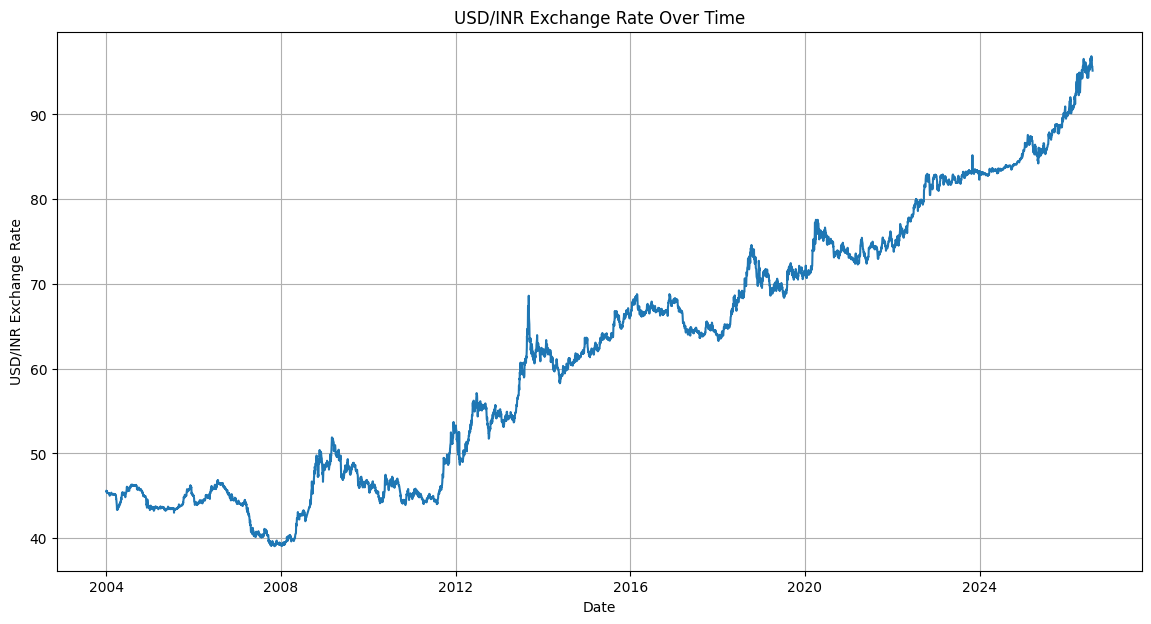

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_close_price, x=df_close_price.index, y='USD/INR')
plt.title('USD/INR Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.grid(True)
plt.show()

### 5.2 ADF and KPSS Tests for Stationarity

To determine if the time series data is stationary, we will perform the Augmented Dickey-Fuller (ADF) test and the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test. Stationarity is a key assumption for many time series forecasting models, such as ARIMA.

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(x):
    # ADF Test
    adf_p = adfuller(x.dropna())[1]

    # KPSS Test
    # regression='c' means the series is stationary around a constant mean (default)
    # The null hypothesis for KPSS is that the series is stationary.
    kpss_p = kpss(x.dropna(), regression='c')[1]

    print(f'ADF p-value  : {adf_p:.5f}')
    print(f'KPSS p-value : {kpss_p:.5f}')

    if adf_p > 0.05 and kpss_p < 0.05:
        print('Conclusion: The series is likely non-stationary.')
    elif adf_p <= 0.05 and kpss_p > 0.05:
        print('Conclusion: The series is likely stationary.')
    else:
        print('Conclusion: Mixed results, further investigation might be needed.')

# Apply the stationarity tests to our USD/INR series
series_usd_inr = df_close_price['USD/INR']
stationarity_tests(series_usd_inr)

ADF p-value  : 0.99127
KPSS p-value : 0.01000
Conclusion: The series is likely non-stationary.


/tmp/ipykernel_2767/880436254.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(x.dropna(), regression='c')[1]


### 5.3 Transformations for Stationarity

Since the series is non-stationary, we will apply transformations to make it stationary. A common approach is to first take the natural logarithm of the series to stabilize variance, and then apply differencing to remove trend components.

In [7]:
import numpy as np

# Apply logarithmic transformation
log_series = np.log(series_usd_inr)

# Apply first-order differencing
diff_series = log_series.diff().dropna()

print('Stationarity tests on log-transformed and differenced series:')
stationarity_tests(diff_series)

# Display the first few rows of the transformed series
print('\nFirst 5 rows of the transformed series:')
display(diff_series.head())

Stationarity tests on log-transformed and differenced series:
ADF p-value  : 0.00000
KPSS p-value : 0.10000
Conclusion: The series is likely stationary.

First 5 rows of the transformed series:


/tmp/ipykernel_2767/880436254.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(x.dropna(), regression='c')[1]


,USD/INR
Date,
2004-01-02,0.001668
2004-01-05,-0.003009
2004-01-06,0.001824
2004-01-07,-0.003563
2004-01-08,0.001783


### 5.4 ACF/PACF Plots

With the series now stationary, we can use Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to help determine the appropriate orders (p and q) for the ARIMA model. These plots show the correlation of the series with its lagged values.

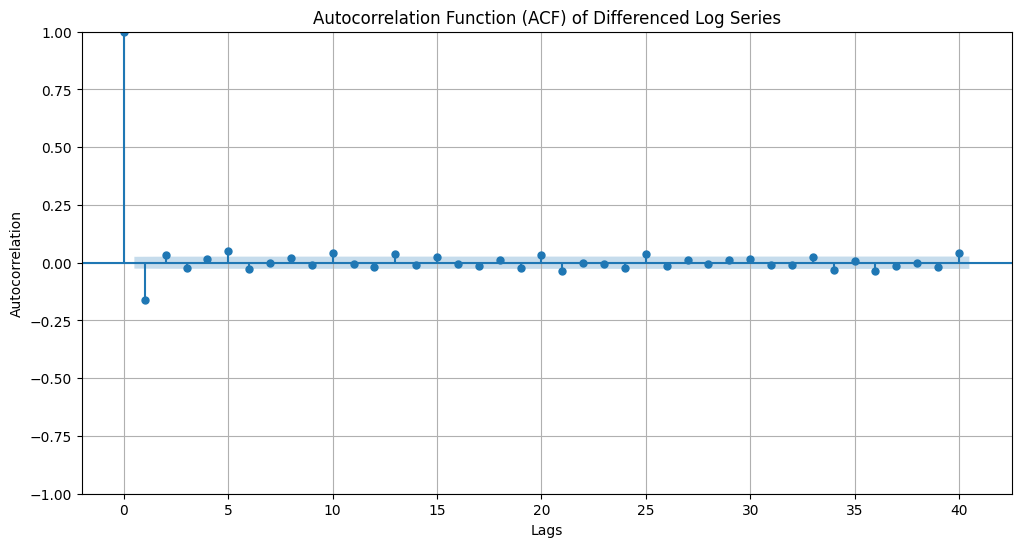

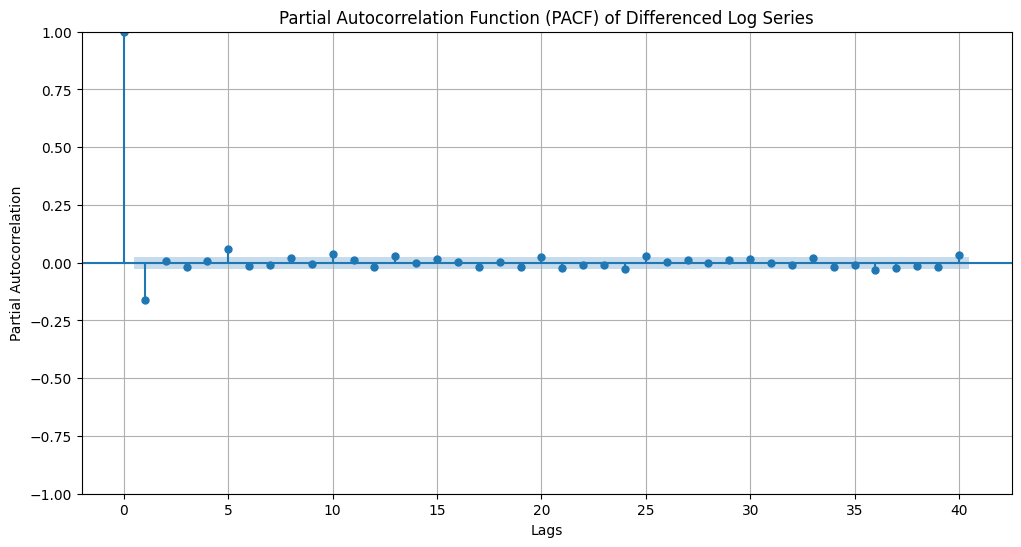

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(diff_series, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Differenced Log Series')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(diff_series, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Differenced Log Series')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

### 5.5 Auto ARIMA Model Selection

Now that we have a stationary series and have analyzed the ACF and PACF plots, we can use `pmdarima.auto_arima` to automatically select the optimal ARIMA model parameters (p, d, q). This function iteratively searches for the best model based on an information criterion (like AIC or BIC).

In [10]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.1 MB/s eta 0:00:00


In [11]:
import pmdarima as pm

# Fit the auto_arima model
arima_model = pm.auto_arima(
    log_series, # Use the log-transformed series, as differencing will be handled by 'd'
    seasonal=False, # Assuming no seasonality for daily data without explicit seasonal patterns
    stepwise=True, # Use stepwise search to find the best model
    trace=True, # Print results of individual ARIMA models fit
    suppress_warnings=True, # Suppress warnings during the search
    error_action='ignore', # Don't stop if a model fails to fit
    max_order=None, # No maximum order, let it determine (p,d,q) freely
    information_criterion='aic' # Use AIC to compare models
)

print('\nAuto ARIMA Model Summary:')
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-46252.414, Time=12.00 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-46105.318, Time=0.61 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-46258.404, Time=0.78 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-46252.477, Time=1.91 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-46103.146, Time=0.36 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-46256.868, Time=5.18 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-46256.964, Time=1.94 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-46254.665, Time=6.32 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-46254.619, Time=0.36 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 29.495 seconds

Auto ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5856
Model:               SARIMAX(1, 1, 0)   Log Likelihood               23132.202
Da

### 5.6 Forecast

In [12]:
n_forecast = 30

# Make predictions on the log-transformed scale
forecast_log = arima_model.predict(n_periods=n_forecast)

# Inverse transform the forecast to the original scale
forecast = np.exp(forecast_log)

print('Forecast for the next 30 periods:')
display(forecast)

Forecast for the next 30 periods:


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,0
5856,95.269072
5857,95.267363
5858,95.281556
5859,95.293179
5860,95.305219
5861,95.317194
5862,95.329181
5863,95.341167
5864,95.353156
5865,95.365145


### 5.7 Residual Diagnostics

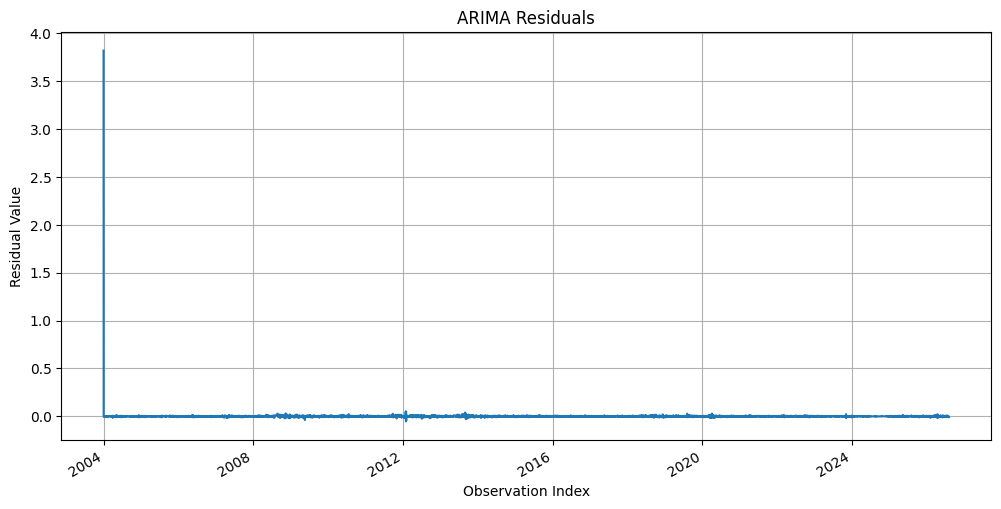

In [13]:
residuals = pd.Series(arima_model.resid())

plt.figure(figsize=(12, 6))
residuals.plot(title='ARIMA Residuals')
plt.xlabel('Observation Index')
plt.ylabel('Residual Value')
plt.grid(True)
plt.show()

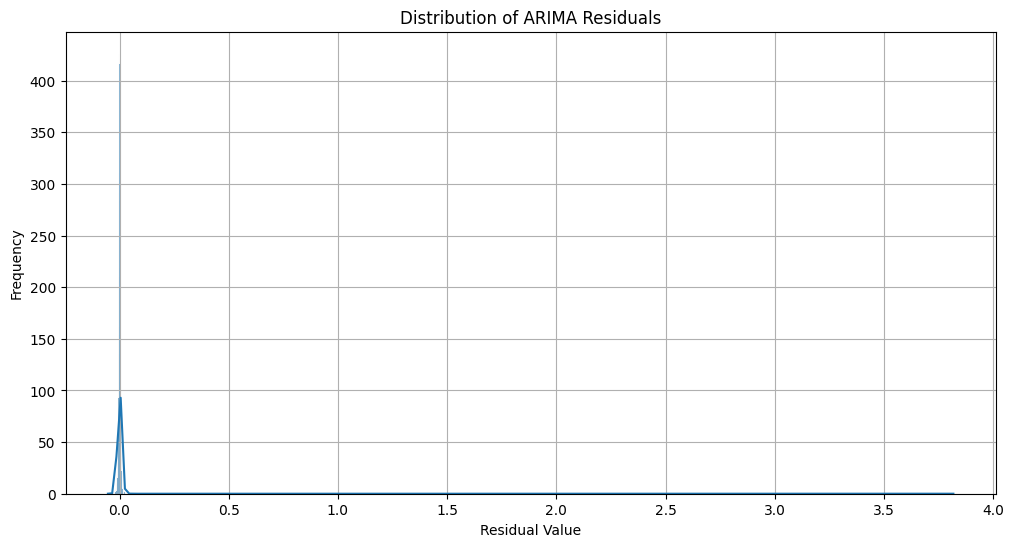

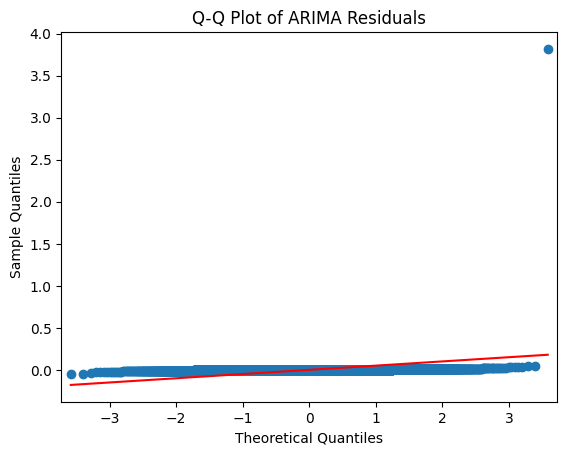

In [14]:
# Further diagnostics: Plotting the distribution of residuals
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of ARIMA Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Q-Q plot for normality test of residuals
import statsmodels.api as sm

sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of ARIMA Residuals')
plt.show()


### Ljung-Box Test for Autocorrelation in Residuals

In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test on residuals
# lags: The number of lags to test for autocorrelation.
# boxpierce: If True, also return the Box-Pierce statistic.
ljung_box_results = acorr_ljungbox(residuals, lags=[10, 20], boxpierce=True)

print('Ljung-Box Test Results for Residuals:')
display(ljung_box_results)

# Interpret the results
# If p-value > 0.05 for several lags, then we fail to reject the null hypothesis
# that the residuals are independently distributed (i.e., no autocorrelation).

for lag, p_value in zip(ljung_box_results.index, ljung_box_results['lb_pvalue']):
    if p_value < 0.05:
        print(f'Lag {lag}: p-value = {p_value:.3f}. Reject H0. Residuals are autocorrelated.')
    else:
        print(f'Lag {lag}: p-value = {p_value:.3f}. Fail to reject H0. Residuals are not autocorrelated.')

Ljung-Box Test Results for Residuals:


,lb_stat,lb_pvalue,bp_stat,bp_pvalue
10,0.015537,1.0,0.015519,1.0
20,0.020099,1.0,0.020067,1.0


Lag 10: p-value = 1.000. Fail to reject H0. Residuals are not autocorrelated.
Lag 20: p-value = 1.000. Fail to reject H0. Residuals are not autocorrelated.


### Plotting Forecast against Actuals

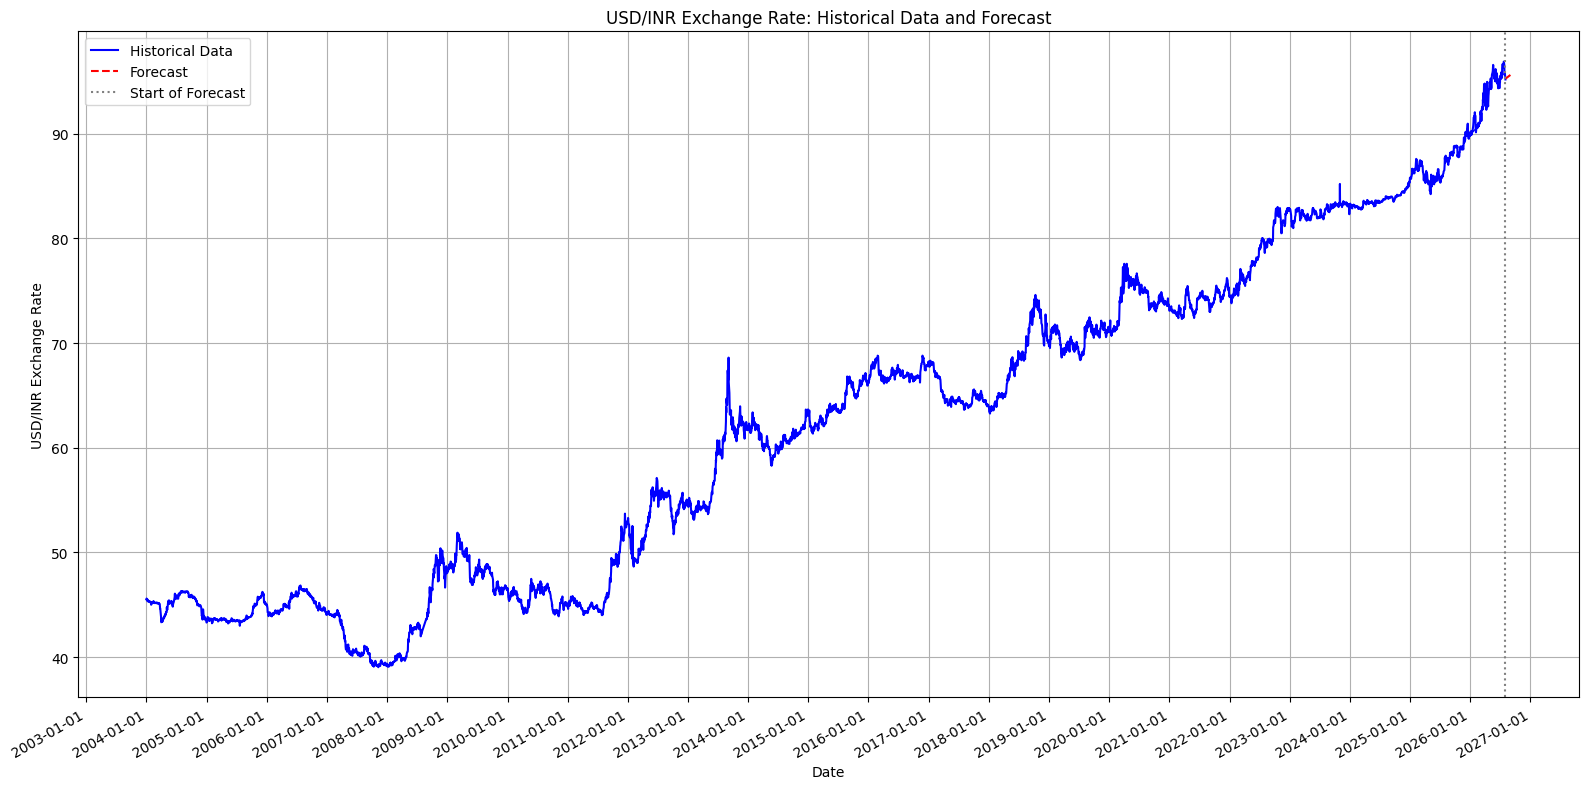

In [16]:
import matplotlib.dates as mdates

# Get the last date from the historical data
last_historical_date = df_close_price.index.max()

# Create a date range for the forecast
# The forecast starts the day after the last historical data point
forecast_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1),
                               periods=n_forecast,
                               freq='D') # Assuming daily frequency, adjust if different

# Create a Series for the forecast with the new date index
forecast_series = pd.Series(forecast.values, index=forecast_dates)

# Combine historical and forecast data for plotting
combined_series = pd.concat([df_close_price['USD/INR'], forecast_series])

plt.figure(figsize=(16, 8))
plt.plot(df_close_price.index, df_close_price['USD/INR'], label='Historical Data', color='blue')
plt.plot(forecast_series.index, forecast_series, label='Forecast', color='red', linestyle='--')

# Highlight the forecast region
plt.axvline(x=last_historical_date, color='gray', linestyle=':', label='Start of Forecast')

plt.title('USD/INR Exchange Rate: Historical Data and Forecast')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.legend()
plt.grid(True)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

### 6.0 Evaluate Forecast Accuracy with RMSE (using a train-test split)

In [17]:
# Split data into training and testing sets
train_size = int(len(log_series) * 0.8)
train_data, test_data = log_series[0:train_size], log_series[train_size:]

print(f"Training data points: {len(train_data)}")
print(f"Test data points: {len(test_data)}")

Training data points: 4684
Test data points: 1172


#### 6.1 Re-fit Auto ARIMA on Training Data

In [18]:
# Re-fit the auto_arima model on the training data
# Using the best parameters found previously to save computation time, or allow auto_arima to find new ones.
# For simplicity, we'll re-run auto_arima on the training set.

arima_model_train = pm.auto_arima(
    train_data,
    seasonal=False,
    stepwise=True,
    trace=False, # Suppress detailed output for brevity during retraining
    suppress_warnings=True,
    error_action='ignore',
    max_order=None,
    information_criterion='aic'
)

print('\nAuto ARIMA Model Summary (on Training Data):')
print(arima_model_train.summary())


Auto ARIMA Model Summary (on Training Data):
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4684
Model:               SARIMAX(1, 1, 0)   Log Likelihood               18205.895
Date:                Mon, 03 Aug 2026   AIC                         -36405.790
Time:                        04:31:41   BIC                         -36386.435
Sample:                             0   HQIC                        -36398.984
                               - 4684                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0001   7.35e-05      1.677      0.094   -2.08e-05       0.000
ar.L1         -0.1654      0.005    -31.671      0.000      -0.176      -0.155
sigma2

#### 6.2 Forecast on Test Set and Calculate RMSE

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Root Mean Squared Error (RMSE) on the test set: 5.2938


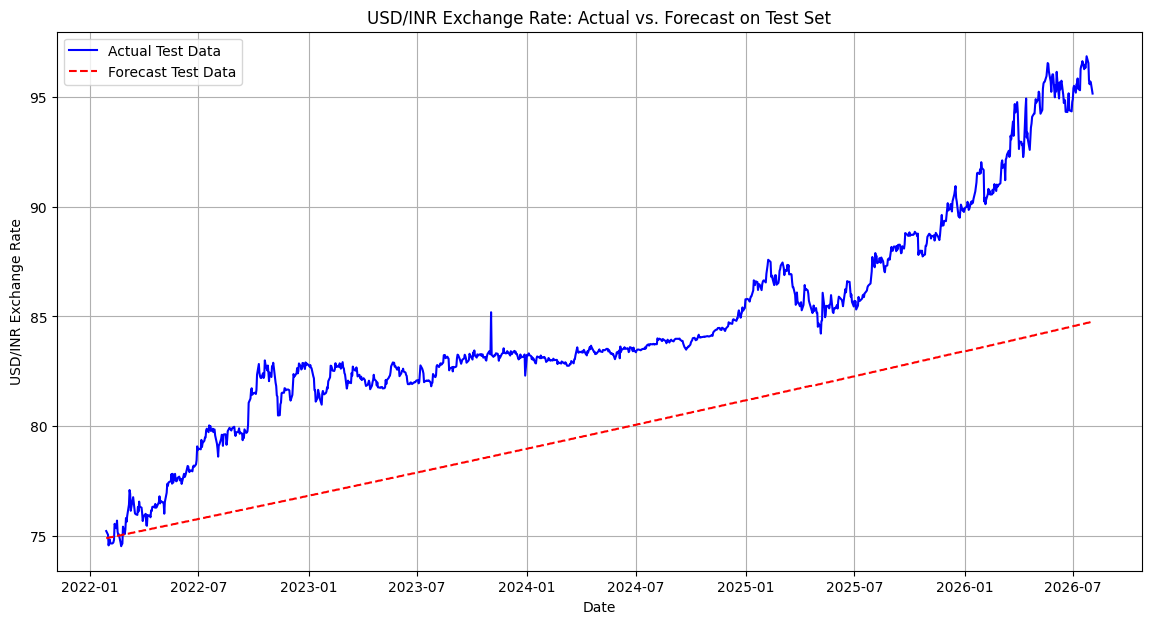

In [20]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Forecast on the test data (log-transformed)
forecast_test_log = arima_model_train.predict(n_periods=len(test_data))

# Inverse transform the forecast and the actual test data to the original scale
forecast_test = np.exp(forecast_test_log)
actual_test = np.exp(test_data)

# Ensure both series have the same index for accurate comparison
# FIX: Extract values from forecast_test to avoid index alignment issues
forecast_test_series = pd.Series(forecast_test.values, index=actual_test.index)

# Calculate RMSE
rmse = sqrt(mean_squared_error(actual_test, forecast_test_series))

print(f'Root Mean Squared Error (RMSE) on the test set: {rmse:.4f}')

# Plot actual vs. forecast for the test set
plt.figure(figsize=(14, 7))
plt.plot(actual_test.index, actual_test, label='Actual Test Data', color='blue')
plt.plot(forecast_test_series.index, forecast_test_series, label='Forecast Test Data', color='red', linestyle='--')
plt.title('USD/INR Exchange Rate: Actual vs. Forecast on Test Set')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

### 7.0 XGBoost Model for Forecasting

#### 7.1 Feature Engineering

For the XGBoost model, we will create several time-series features such as lagged values, rolling means, rolling standard deviations, and Exponential Moving Averages (EMAs). These features will capture temporal dependencies and trends in the data, which XGBoost can then use for prediction. We will use the original `series_usd_inr` for this.


In [21]:
feat = pd.DataFrame({'y': series_usd_inr})

# Lagged features
feat['lag_1'] = feat['y'].shift(1)
feat['lag_7'] = feat['y'].shift(7)
feat['lag_30'] = feat['y'].shift(30)

# Rolling statistics
feat['roll_mean_7'] = feat['y'].rolling(7).mean()
feat['roll_std_7'] = feat['y'].rolling(7).std()

# Exponential Moving Averages (EMAs)
feat['ema_10'] = feat['y'].ewm(span=10).mean()
feat['ema_50'] = feat['y'].ewm(span=50).mean()

# Trend feature
feat['trend'] = range(len(feat))

# Drop rows with NaN values resulting from feature creation
feat = feat.dropna()

print("Features created for XGBoost:")
display(feat.head())

Features created for XGBoost:


,y,lag_1,lag_7,lag_30,roll_mean_7,roll_std_7,ema_10,ema_50,trend
Date,,,,,,,,,
2004-02-12,45.200001,45.188000,45.208000,45.527000,45.192429,0.014165,45.198813,45.263910,30
2004-02-13,45.362000,45.200001,45.209000,45.603001,45.214286,0.066256,45.228532,45.269238,31
2004-02-16,45.181999,45.362000,45.206001,45.466000,45.210857,0.067368,45.220060,45.264570,32
2004-02-17,45.200001,45.181999,45.167999,45.549000,45.215428,0.065020,45.216409,45.261164,33
2004-02-18,45.169998,45.200001,45.192001,45.387001,45.212285,0.066848,45.207963,45.256419,34


#### 7.2 Train/Test Split

We will split the feature-engineered data into training and testing sets. The training set will be used to train the XGBoost model, and the testing set will be used to evaluate its performance on unseen data. We'll use an 80/20 split, similar to the ARIMA model setup.

In [22]:
# Define the split point (80% for training, 20% for testing)
split_point = int(len(feat) * 0.8)

# Split the feature DataFrame
train_df = feat.iloc[:split_point]
test_df = feat.iloc[split_point:]

# Separate features (X) and target (y) for training and testing sets
X_train = train_df.drop('y', axis=1)
y_train = train_df['y']

X_test = test_df.drop('y', axis=1)
y_test = test_df['y']

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

print("\nX_train head:")
display(X_train.head())
print("\ny_train head:")
display(y_train.head())

Training set size: 4660 samples
Test set size: 1166 samples

X_train head:


,lag_1,lag_7,lag_30,roll_mean_7,roll_std_7,ema_10,ema_50,trend
Date,,,,,,,,
2004-02-12,45.188000,45.208000,45.527000,45.192429,0.014165,45.198813,45.263910,30
2004-02-13,45.200001,45.209000,45.603001,45.214286,0.066256,45.228532,45.269238,31
2004-02-16,45.362000,45.206001,45.466000,45.210857,0.067368,45.220060,45.264570,32
2004-02-17,45.181999,45.167999,45.549000,45.215428,0.065020,45.216409,45.261164,33
2004-02-18,45.200001,45.192001,45.387001,45.212285,0.066848,45.207963,45.256419,34



y_train head:


,y
Date,
2004-02-12,45.200001
2004-02-13,45.362000
2004-02-16,45.181999
2004-02-17,45.200001
2004-02-18,45.169998


#### 7.3 Train XGBoost Model

We will now train an XGBoost Regressor model using the engineered features. XGBoost is a powerful gradient boosting framework known for its performance and speed. We'll define a set of hyper-parameters and then fit the model to our training data.

In [23]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor with specified parameters
xgb_model = XGBRegressor(
    n_estimators=300,        # Number of boosting rounds
    learning_rate=0.05,      # Step size shrinkage to prevent overfitting
    max_depth=5,             # Maximum depth of a tree
    subsample=0.8,           # Subsample ratio of the training instance
    colsample_bytree=0.8,    # Subsample ratio of columns when constructing each tree
    random_state=42          # For reproducibility
)

# Fit the model to the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred = xgb_model.predict(X_test)

print("XGBoost model training complete and predictions made on the test set.")
print("First 5 predictions:")
display(xgb_pred[:5])

XGBoost model training complete and predictions made on the test set.
First 5 predictions:


array([74.843666, 74.74987 , 74.79632 , 74.828896, 74.904816],
      dtype=float32)

#### 7.4 Evaluate XGBoost Model Performance (RMSE)

We will now calculate the Root Mean Squared Error (RMSE) to quantify the accuracy of our XGBoost model's predictions on the test set. A lower RMSE indicates a better fit of the model to the data.

Root Mean Squared Error (RMSE) for XGBoost on the test set: 9.6468


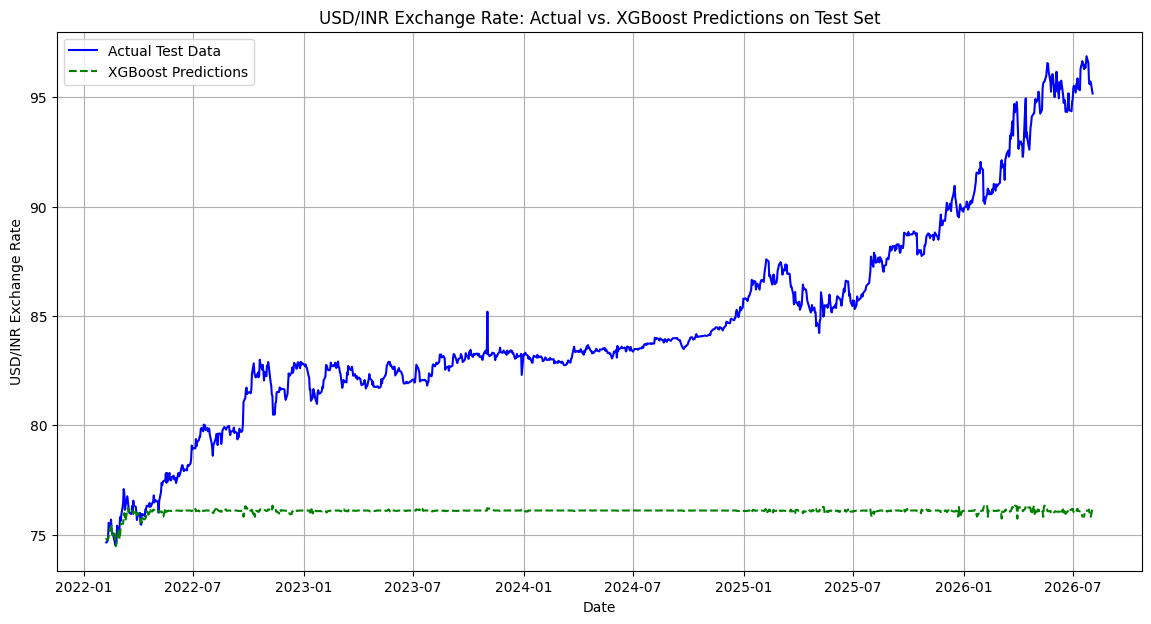

In [24]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate RMSE for XGBoost predictions
rmse_xgb = sqrt(mean_squared_error(y_test, xgb_pred))

print(f'Root Mean Squared Error (RMSE) for XGBoost on the test set: {rmse_xgb:.4f}')

# Plot actual vs. predicted for the test set
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Test Data', color='blue')
plt.plot(y_test.index, xgb_pred, label='XGBoost Predictions', color='green', linestyle='--')

plt.title('USD/INR Exchange Rate: Actual vs. XGBoost Predictions on Test Set')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

### 8.0 Deep Learning Preparation

#### 8.1 Normalize Data

Deep learning models often perform better when input data is scaled. We'll use `MinMaxScaler` to normalize the `series_usd_inr` data to a range between 0 and 1.

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Reshape the series to a 2D array and fit-transform
scaled_data = scaler.fit_transform(series_usd_inr.values.reshape(-1, 1))

print("Original series_usd_inr head:")
display(series_usd_inr.head())
print("\nScaled data head:")
display(scaled_data[:5])

Original series_usd_inr head:


,USD/INR
Date,
2004-01-01,45.527000
2004-01-02,45.603001
2004-01-05,45.466000
2004-01-06,45.549000
2004-01-07,45.387001



Scaled data head:


array([[0.11208351],
       [0.11339766],
       [0.11102871],
       [0.11246391],
       [0.10966271]])

#### 8.2 Create Sequences for Time Series

For recurrent neural networks (RNNs) like SimpleRNN and LSTM, data needs to be structured into sequences. We'll create input sequences (X) and corresponding target values (y) based on a defined `WINDOW` size.

In [26]:
import numpy as np

# Define the window size for creating sequences
WINDOW = 30

X, y = [], []

for i in range(WINDOW, len(scaled_data)):
    X.append(scaled_data[i-WINDOW:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape X for RNN input (samples, time_steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Shape of X (sequences): {X.shape}")
print(f"Shape of y (targets): {y.shape}")
print("\nFirst sequence (X[0]):")
display(X[0])
print("\nFirst target (y[0]):")
display(y[0])

Shape of X (sequences): (5826, 30, 1)
Shape of y (targets): (5826,)

First sequence (X[0]):


array([[0.11208351],
       [0.11339766],
       [0.11102871],
       [0.11246391],
       [0.10966271],
       [0.11106327],
       [0.10904023],
       [0.10891919],
       [0.10838311],
       [0.10864248],
       [0.1090056 ],
       [0.10859063],
       [0.10869439],
       [0.10864248],
       [0.10827936],
       [0.10852144],
       [0.10719   ],
       [0.10689607],
       [0.10765687],
       [0.1073456 ],
       [0.10765687],
       [0.10304007],
       [0.10599688],
       [0.10656751],
       [0.1065848 ],
       [0.10653295],
       [0.10587584],
       [0.10629087],
       [0.10615248],
       [0.10622168]])


First target (y[0]):


np.float64(0.10642919269464979)

### 9.0 RNN Model

We will now define and compile a SimpleRNN model using TensorFlow/Keras. This model will take the sequences created in the previous step as input and predict the next value in the series.

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Define the SimpleRNN model
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(X.shape[1], 1)),
    Dense(1)
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='mse')

print('SimpleRNN model defined and compiled:')
rnn_model.summary()

SimpleRNN model defined and compiled:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

### 10.0 LSTM Model

Next, we will define and compile an LSTM (Long Short-Term Memory) model. LSTMs are a type of RNN particularly well-suited for learning long-term dependencies in sequential data, often outperforming simple RNNs on complex time series tasks.

In [28]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X.shape[1], 1)),
    Dense(1)
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='mse')

print('LSTM model defined and compiled:')
lstm_model.summary()

LSTM model defined and compiled:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

[link text](https:// [link text](https://))### 12.0 Train and Evaluate SimpleRNN Model

We will now train the SimpleRNN model using our prepared training data and then evaluate its performance on the test set. We'll use Root Mean Squared Error (RMSE) as the evaluation metric.

Training SimpleRNN model...
SimpleRNN model training complete.
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Root Mean Squared Error (RMSE) for SimpleRNN on the test set: 0.6632


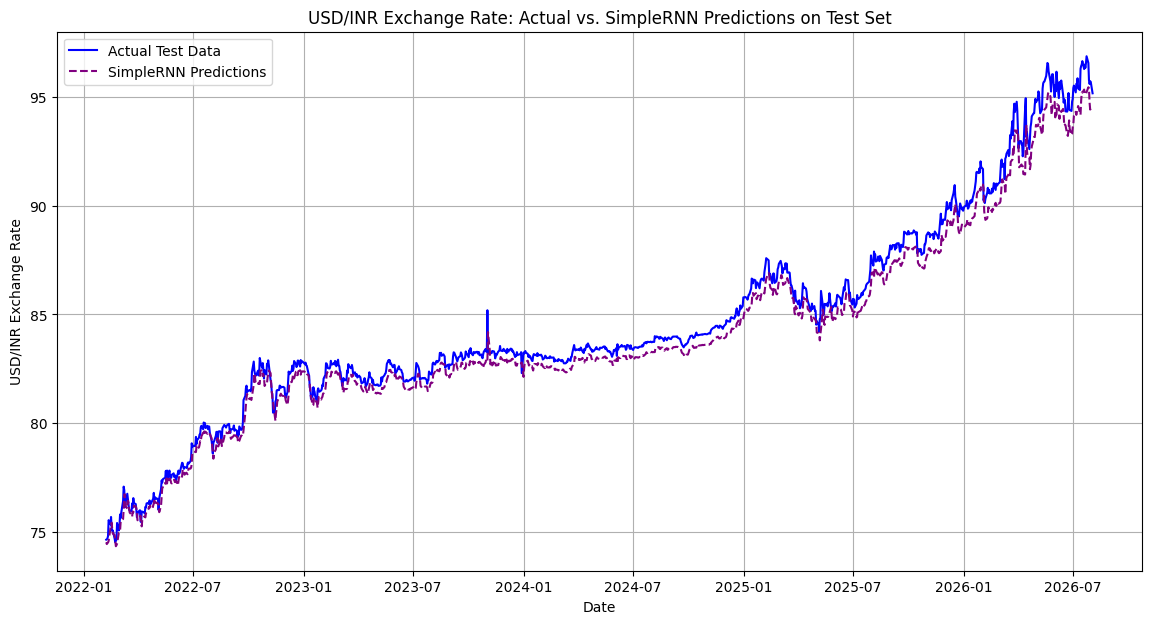

In [32]:
print('Training SimpleRNN model...')

# Train the SimpleRNN model
rnn_model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=32, verbose=0)

print('SimpleRNN model training complete.')

# Make predictions on the test set
rnn_pred_scaled = rnn_model.predict(X_test_dl)

# Inverse transform the predictions and actual values to the original scale
rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
actual_dl_test = scaler.inverse_transform(y_test_dl.reshape(-1, 1))

# Calculate RMSE
rmse_rnn = sqrt(mean_squared_error(actual_dl_test, rnn_pred))

print(f'Root Mean Squared Error (RMSE) for SimpleRNN on the test set: {rmse_rnn:.4f}')

# Plot actual vs. predicted for the test set
plt.figure(figsize=(14, 7))
plt.plot(df_close_price.index[split_dl + WINDOW:], actual_dl_test, label='Actual Test Data', color='blue')
plt.plot(df_close_price.index[split_dl + WINDOW:], rnn_pred, label='SimpleRNN Predictions', color='purple', linestyle='--')
plt.title('USD/INR Exchange Rate: Actual vs. SimpleRNN Predictions on Test Set')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

### 13.0 Train and Evaluate LSTM Model

Finally, we will train the LSTM model and evaluate its performance on the test set, similar to the SimpleRNN model. This will allow us to compare its effectiveness in forecasting the USD/INR exchange rate.

Training LSTM model...
LSTM model training complete.
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Root Mean Squared Error (RMSE) for LSTM on the test set: 0.2900


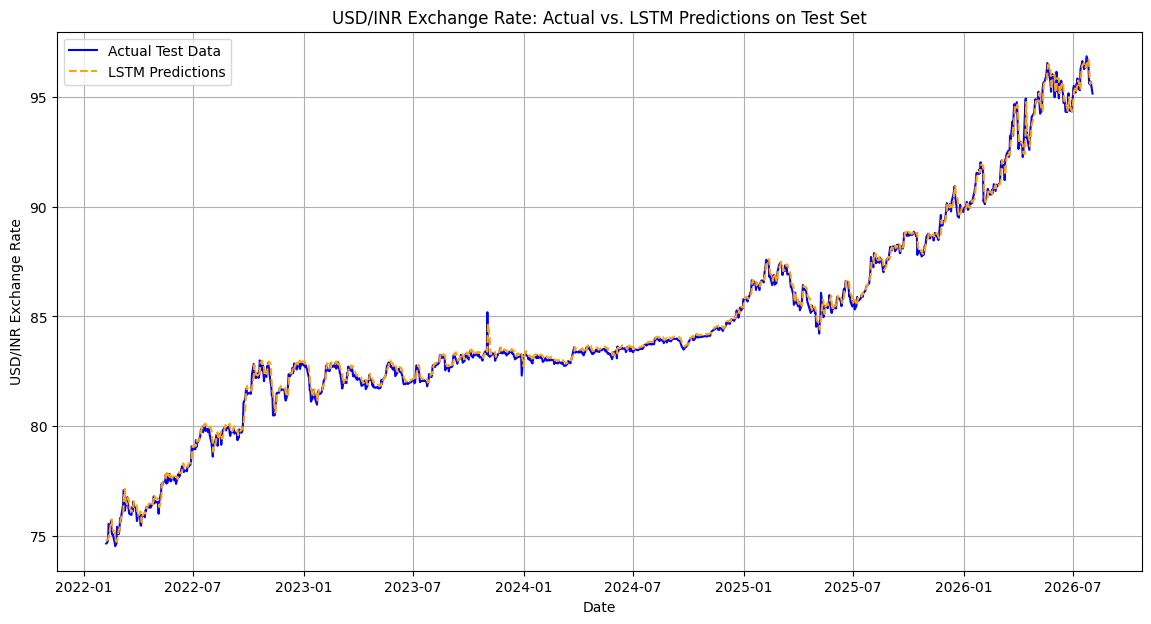

In [33]:
print('Training LSTM model...')

# Train the LSTM model
lstm_model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=32, verbose=0)

print('LSTM model training complete.')

# Make predictions on the test set
lstm_pred_scaled = lstm_model.predict(X_test_dl)

# Inverse transform the predictions and actual values to the original scale
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
actual_dl_test = scaler.inverse_transform(y_test_dl.reshape(-1, 1))

# Calculate RMSE
rmse_lstm = sqrt(mean_squared_error(actual_dl_test, lstm_pred))

print(f'Root Mean Squared Error (RMSE) for LSTM on the test set: {rmse_lstm:.4f}')

# Plot actual vs. predicted for the test set
plt.figure(figsize=(14, 7))
plt.plot(df_close_price.index[split_dl + WINDOW:], actual_dl_test, label='Actual Test Data', color='blue')
plt.plot(df_close_price.index[split_dl + WINDOW:], lstm_pred, label='LSTM Predictions', color='orange', linestyle='--')
plt.title('USD/INR Exchange Rate: Actual vs. LSTM Predictions on Test Set')
plt.xlabel('Date')
plt.ylabel('USD/INR Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

### 11.0 Deep Learning Train/Test Split

Similar to the previous models, we will split our sequenced data (`X` and `y`) into training and testing sets. This split is essential to evaluate how well our deep learning models generalize to unseen data. We'll use an 80/20 split for consistency.

In [29]:
# Define the split point (80% for training, 20% for testing) for deep learning data
split_dl = int(len(X) * 0.8)

# Split the sequences and targets
X_train_dl, X_test_dl = X[:split_dl], X[split_dl:]
y_train_dl, y_test_dl = y[:split_dl], y[split_dl:]

print(f"X_train_dl shape: {X_train_dl.shape}")
print(f"y_train_dl shape: {y_train_dl.shape}")
print(f"X_test_dl shape: {X_test_dl.shape}")
print(f"y_test_dl shape: {y_test_dl.shape}")

X_train_dl shape: (4660, 30, 1)
y_train_dl shape: (4660,)
X_test_dl shape: (1166, 30, 1)
y_test_dl shape: (1166,)
